## PROBLEM STATEMENT
Analyze user behavior in an e-commerce platform to identify drop-off points in the purchase funnel and provide actionable recommendations to improve conversion rates and user retention.

### Data Understanding
- The dataset contains ~3.5 million records of user interactions on an e-commerce platform.
Key columns include:
- event_time: Timestamp of user activity
- event_type: Type of action (view, cart, purchase)
- user_id: Unique user identifier
- product_id: Product identifier
- price: Product price
- The dataset captures the complete user journey, enabling analysis of conversion funnel and retention behavior.
Some columns like category_code contain missing values and are not used in the analysis.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('2019-Dec.csv')

In [4]:
df.head(2)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 242.6+ MB


In [7]:
df['event_type'].value_counts()

event_type
view                1728331
cart                 927124
remove_from_cart     664655
purchase             213176
Name: count, dtype: int64

In [8]:
# Step 3: Calculating unique users at each funnel stage
funnel = df.groupby('event_type')['user_id'].nunique()
print(funnel)

event_type
cart                 83458
purchase             25613
remove_from_cart     45217
view                358212
Name: user_id, dtype: int64


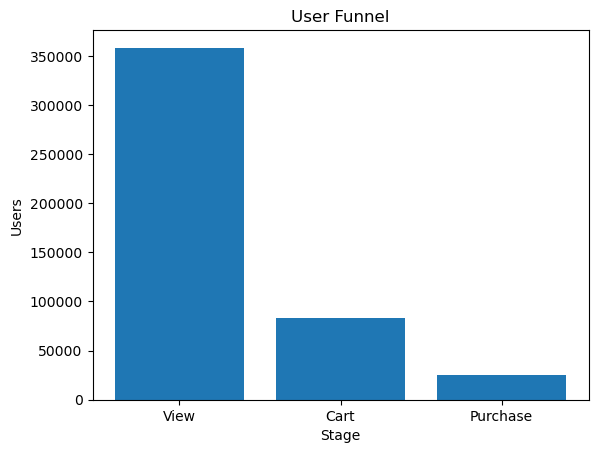

In [14]:
# Funnel Chart
funnel_data = [358212, 83458, 25613]
stages = ['View', 'Cart', 'Purchase']

plt.bar(stages, funnel_data)
plt.title("User Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.show()

### Insights:
1. **Only ~23% of users progress from product view to cart**, indicating a significant drop-off at the product exploration stage.
2. **Cart to purchase conversion (~31%) is relatively strong**, suggesting that users who show purchase intent are more likely to      complete transactions.
3. **The funnel is highly top-heavy**, meaning a large portion of users browse but do not engage deeply with products.
4. **High cart abandonment is observed (~45K users removing items from cart)**, indicating possible issues like pricing concerns, unexpected costs, or checkout friction.

In [10]:
# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'])

In [11]:
# Step 4: Identify first visit (cohort) for each user
df['first_visit'] = df.groupby('user_id')['event_time'].transform('min')

# Convert to month (cohort month)
df['cohort_month'] = df['first_visit'].dt.to_period('M')

df.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7232\2966623198.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['cohort_month'] = df['first_visit'].dt.to_period('M')


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,first_visit,cohort_month
0,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019-12-01 00:00:00+00:00,2019-12
1,2019-12-01 00:00:00+00:00,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019-12-01 00:00:00+00:00,2019-12
2,2019-12-01 00:00:02+00:00,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019-12-01 00:00:02+00:00,2019-12
3,2019-12-01 00:00:05+00:00,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,2019-12-01 00:00:05+00:00,2019-12
4,2019-12-01 00:00:07+00:00,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019-12-01 00:00:07+00:00,2019-12


In [12]:
# Step 5: Calculate days since first visit
df['days_since_first_visit'] = (df['event_time'] - df['first_visit']).dt.days

In [13]:
# Step 6: Retention by days
retention_day = df.groupby('days_since_first_visit')['user_id'].nunique()

retention_day.head(10)

days_since_first_visit
0    370154
1     17964
2     12869
3     10587
4      9247
5      8269
6      8028
7      7663
8      6685
9      6001
Name: user_id, dtype: int64

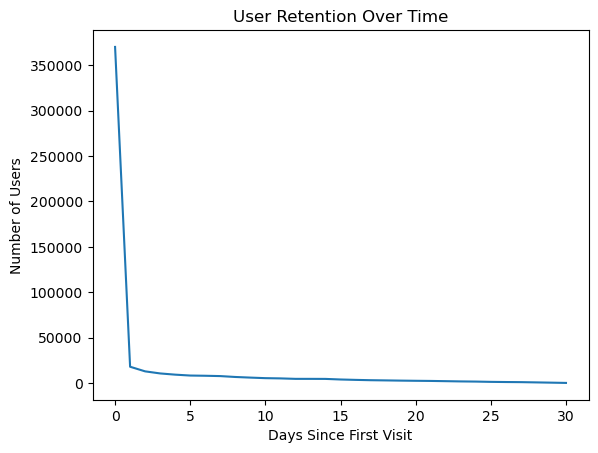

In [15]:
#Retention Curve
retention_day.plot()
plt.title("User Retention Over Time")
plt.xlabel("Days Since First Visit")
plt.ylabel("Number of Users")
plt.show()

### Retention Insights:
1. **User retention drops sharply after the first day, with only ~4–5% of users returning on Day 1**, indicating very low short-term engagement.
2. **Retention continues to decline steadily over time, falling below ~2% by Day 7**, suggesting poor long-term user retention.
3. **The majority of users interact with the platform only once**, highlighting a lack of repeat engagement.
4. **Low retention combined with high top-of-funnel traffic indicates weak user stickiness**, meaning users are not finding enough value to return.

## Business Recommendation:
1. Improve product page experience to reduce drop-off at the view stage
2. Introduce incentives (discounts/offers) to encourage cart additions
3. Optimize checkout process to reduce cart abandonment
4. Implement retargeting strategies (emails/notifications) to improve retention
5. Personalize product recommendations to increase repeat engagement